<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
        - [3.1.1 Single-label VS Multi-label Classification](#P3.1.1)
        - [3.1.1 Similarity between restaurant categories](#P3.1.2)
        - [3.1.2 Empty Restaurant Reviews](#P3.1.3)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from classification_prep import *
from modelling import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/02_atlanta_restaurant_slice_2023_translated.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,-84.410451,3,"One word amazing!! The red fish, halibut, frie...",en,en,False,"One word amazing!! The red fish, halibut, frie...","One word amazing!! The red fish, halibut, frie..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,False,3349,33.779814,-84.410451,1,First time here and the food is great and the ...,en,en,False,First time here and the food is great and the ...,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,False,3349,33.779814,-84.410451,14,I recently had the pleasure of dining at Optim...,en,en,False,I recently had the pleasure of dining at Optim...,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,False,3349,33.779814,-84.410451,9,Beautiful atmosphere and delicious food . All ...,en,en,False,Beautiful atmosphere and delicious food . All ...,Beautiful atmosphere and delicious food . All ...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,3349,33.779814,-84.410451,3,We had a wonderful dinner at the Optimist . Ou...,en,en,False,We had a wonderful dinner at the Optimist . Ou...,We had a wonderful dinner at the Optimist . Ou...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53565 entries, 0 to 53564
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   title                           53565 non-null  object 
 1   categoryName                    53565 non-null  object 
 2   website                         50599 non-null  object 
 3   url                             53565 non-null  object 
 4   reviewsCount                    53565 non-null  int64  
 5   stars                           53565 non-null  float64
 6   text                            53565 non-null  object 
 7   is_chain                        53565 non-null  bool   
 8   total_reviews_by_title          53565 non-null  int64  
 9   latitude                        53565 non-null  float64
 10  longitude                       53565 non-null  float64
 11  num_sentences                   53565 non-null  int64  
 12  00_before_translating_cleaning  

| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

From the data exploration stage (Notebooks 01 and 02), several key insights emerged:

(*01_data_understtanding.ipynb*)
- The restaurant category with more restaurants its ``Mexican Restaurant`` with 8959 and at last ``Bar & grill`` with 1107 restaurants
- In our raw dataset, we observe that the **exact same review text** appears multiple times. (MultiLabel Problem)

(*02_general_data_prep.ipynb*)
- The majority of reviews in the `text` column are **short**, consisting of **1–2 sentences**. The `num_sentences` distribution supports this: 
    - median = $2$
    - $75^{th}$ percentile = $4$
    - maximum = $43$

    suggesting a few exceptionally long reviews.

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [7]:
#Next cells are already done in the data prep notebook
dataset["categoryName"].value_counts().reset_index()

,categoryName,count
0,Mexican restaurant,8959
1,Fast food restaurant,5324
2,Italian restaurant,5108
3,American restaurant,5049
4,Pizza restaurant,4560
5,Breakfast restaurant,2491
6,Chinese restaurant,2484
7,Seafood restaurant,2048
8,Hamburger restaurant,1979
9,New American restaurant,1903


In [8]:
unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

# Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["text"] = dataset["text"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

<Axes: >

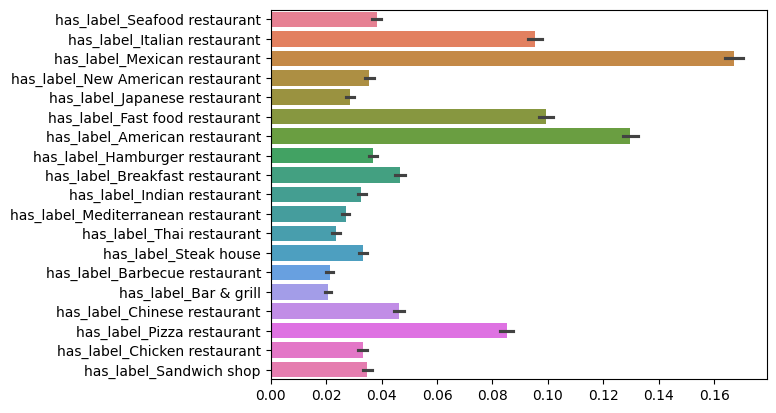

In [9]:
sns.barplot(dataset_explore, orient="h")

### <font color='#BFD72F' size=6>3.1.1 Similarity between restaurant categories</font> <a class="anchor" id="P3.1.1"></a>
  
[Back to TOC](#toc)

# Initial Text Preprocessing: Baseline Cleaning

In this first step, we create a normalized version of the dataset to analyze the text structure and category similarities **before** filtering.

We apply the `main_pipeline` with the following configuration:
* **Noise Removal:** Stripping emojis, hashtags, URLs, and punctuation to reduce noise.
* **Lemmatization (`lemmatized=True`):** Converting words to their base forms (e.g., "running" $\to$ "run") to consolidate the vocabulary.
* **Stopwords Retention (`no_stopwords=False`):** We intentionally **keep** stopwords (e.g., "the", "and", "is") at this stage. This allows us to observe the natural language distribution and similarity between categories before removing grammatical connectors.

In [10]:
dataset['with_stopwords_cleaned_review_body'] =\
    dataset['text_for_pipeline'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=False,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [11]:
category_reviews = dataset.groupby("categoryName")["with_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["with_stopwords_cleaned_review_body"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

Analyizing first the similarity of the language used in the reviews between different categories before removing stop words.

In [12]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

As observed, the great majority of categories share a very high similarity. This indicates that the language used in reviews is quite consistent across different restaurant types. 

This high overlap is largely **due to the presence of stopwords and common words** (e.g., "the", "no", "it", "is") that appear in everyday language regardless of the specific cuisine. If this "noise" is not treated, the model may struggle to distinguish between categories, as the unique signals for each cuisine are drowned out by common vocabulary.

Now analyzing the similarity again after removing stopwords and other common words across all reviews.

In [13]:
dataset['without_stopwords_cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [14]:
category_reviews_cleaned1 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix1 = vectorizer.fit_transform(category_reviews_cleaned1["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned1 = cosine_similarity(tfidf_matrix1)

similarity_df_cleaned1 = pd.DataFrame(
    similarity_matrix_cleaned1,
    index=category_reviews_cleaned1["categoryName"],
    columns=category_reviews_cleaned1["categoryName"])

heatmap_chart(similarity_df_cleaned1,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### Impact of Stopword Removal & Category Merging

**1. Reduced Similarity:**
As expected, removing stopwords and common words significantly decreased the similarity between categories. This indicates that the unique vocabulary of each cuisine becomes more pronounced when generic terms are excluded, allowing for clearer distinction between restaurant types. This confirms that stopword removal is a necessary step before classification.

**2. Handling High Overlap (American & Steakhouse):**
Upon analyzing the new correlation matrix, three specific categories still retained high similarity scores: *"New American restaurant"*, *"American restaurant"*, and *"Steak house"*. This suggests a strong linguistic overlap in how customers review these establishments. 

To address this and avoid model confusion, we decided to **merge these three distinct labels into a single category**: **"American & Steakhouse"**. For the remainder of this project (Exploration and Classification), these three will be treated as one unified class.

In [15]:
# joining the three categories into one : 'American & Steakhouse'
dataset['categoryName'] = dataset['categoryName'].replace({
    'American restaurant': 'American & Steakhouse',
    'New American restaurant': 'American & Steakhouse',
    'Steak house': 'American & Steakhouse',
    
})

In [16]:
category_reviews_cleaned2 = dataset.groupby("categoryName")["without_stopwords_cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix2 = vectorizer.fit_transform(category_reviews_cleaned2["without_stopwords_cleaned_review_body"])

similarity_matrix_cleaned2 = cosine_similarity(tfidf_matrix2)

similarity_df_cleaned2 = pd.DataFrame(
    similarity_matrix_cleaned2,
    index=category_reviews_cleaned2["categoryName"],
    columns=category_reviews_cleaned2["categoryName"])

heatmap_chart(similarity_df_cleaned2,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

### <font color='#BFD72F' size=6>3.1.3 Empty Restaurant Reviews</font> <a class="anchor" id="P3.1.3"></a>
  
[Back to TOC](#toc)

Before proceeding with classification, we must handle "ghost" reviews—entries that became empty after our initial cleaning pipeline.

First, we analyze the `with_stopwords_cleaned_review_body` column. These are reviews where we have removed noise (URLs, emojis, special characters) but **kept** the stopwords.
* **Logic:** If a review is empty at this stage, it means the original text contained **no valid words** at all (e.g., a review containing only "!!!" or "🍔").
* **Action:** Since these rows contain zero linguistic information, we **drop them** from the dataset to prevent errors in the modeling phase.

In [17]:
# Count the number of exactly empty reviews
empty_with_stopwords = (dataset["with_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces_with_stopwords = dataset["with_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""]["with_stopwords_cleaned_review_body"].head(10)
print("Exactly empty reviews:", empty_with_stopwords)
print("Reviews with only spaces (or tabs):", empty_spaces_with_stopwords)
print("\nExamples of empty reviews:")
print(examples_with_stopwords)

Exactly empty reviews: 0
Reviews with only spaces (or tabs): 0

Examples of empty reviews:
Series([], Name: with_stopwords_cleaned_review_body, dtype: object)


In [18]:
empty_idx_with_stopwords = dataset[dataset["with_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx_with_stopwords, :]

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline,with_stopwords_cleaned_review_body,without_stopwords_cleaned_review_body


In [19]:
dataset.drop(empty_idx_with_stopwords, inplace=True)
print((dataset["with_stopwords_cleaned_review_body"].str.strip() == "").sum())

0


Next, we examine the `without_stopwords_cleaned_review_body` column.
* **Logic:** These are reviews that were not empty initially, but became empty **after** we removed common stopwords (like "the", "was", "and").
* **Meaning:** A review ending up here implies it was composed entirely of generic grammatical words (e.g., *"It was all..."*) and lacked specific nouns or adjectives relevant to the cuisine.
* **Action:** We calculate the count of these "hollow" reviews to understand how much data might be lost or rendered non-informative by stopword filtering.

In [20]:
# Count the number of exactly empty reviews
empty_without_stopwords = (dataset["without_stopwords_cleaned_review_body"] == "").sum()

# Count reviews that only have spaces or tabs
empty_spaces_without_stopwords = dataset["without_stopwords_cleaned_review_body"].str.strip().eq("").sum()

# Show examples (first 10)
examples_without_stopwords = dataset[dataset["without_stopwords_cleaned_review_body"].str.strip() == ""]["without_stopwords_cleaned_review_body"].head(10)

print("Exactly empty reviews:", empty_without_stopwords)
print("Reviews with only spaces (or tabs):", empty_spaces_without_stopwords)
print("\nExamples of empty reviews:")
print(examples_without_stopwords)

Exactly empty reviews: 12
Reviews with only spaces (or tabs): 12

Examples of empty reviews:
12254    
13730    
14009    
25856    
28726    
29359    
32203    
36174    
37181    
40580    
Name: without_stopwords_cleaned_review_body, dtype: object


In [21]:
empty_idx_without_stopwords = dataset[dataset["without_stopwords_cleaned_review_body"].str.strip() == ""].index

#show the rows with empty cleaned reviews
dataset.loc[empty_idx_without_stopwords, :]

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude,num_sentences,00_before_translating_cleaning,lang_langdetect,lang_langid,needs_translation,text_translated,text_for_pipeline,with_stopwords_cleaned_review_body,without_stopwords_cleaned_review_body
12254,Marlow's Tavern,American & Steakhouse,http://www.marlowstavern.com/locations/dunwoody,https://www.google.com/maps/place/Marlow's+Tav...,668,3.0,The,True,1799,33.950040,-84.334998,1,The,en,en,False,The,The,the,
13730,Buon Fornello Café & Bottega,Italian restaurant,http://www.buonfornello.com/,https://www.google.com/maps/place/Buon+Fornell...,332,5.0,A++++,False,332,33.919896,-84.352272,1,A++++,hu,en,True,A++++,A++++,a,
14009,Baraonda Ristorante & Bar,Italian restaurant,http://www.baraondaatlanta.com/,https://www.google.com/maps/place/Baraonda+Ris...,955,2.0,Just,False,955,33.920937,-84.378772,1,Just,et,en,True,Just,Just,just,
25856,Taco mexico,Mexican restaurant,http://taco-mexico.com/,https://www.google.com/maps/place/Taco+mexico/...,310,1.0,We,False,310,34.195679,-84.135397,1,We,de,en,True,We,We,we,
28726,Hardee’s,Fast food restaurant,https://locations.hardees.com/ga/cumming/125-w...,https://www.google.com/maps/place/Hardee%E2%80...,907,3.0,Not what they were,False,907,34.206418,-84.141298,1,Not what they were,en,en,False,Not what they were,Not what they were,not what they were,
29359,Wendy's,Fast food restaurant,https://locations.wendys.com/united-states/ga/...,https://www.google.com/maps/place/Wendy's/@34....,628,1.0,Just no,True,3838,34.186582,-84.140130,1,Just no,en,en,False,Just no,Just no,just no,
32203,Jimmy John's,Sandwich shop,https://locations.jimmyjohns.com/ga/peachtreec...,https://www.google.com/maps/place/Jimmy+John's...,233,5.0,A+++,True,409,33.396506,-84.602057,1,A+++,hu,en,True,A+++,A+++,a,
36174,Ranchero Bar & Grill (Westpark),Mexican restaurant,http://www.elrancheropeachtreecity.com/?fbclid...,https://www.google.com/maps/place/Ranchero+Bar...,750,2.0,Not for me.,False,750,33.398291,-84.590100,1,Not for me.,no,en,True,Not for me.,Not for me.,not for me,
37181,PITA Mediterranean Street Food,Mediterranean restaurant,NaN,https://www.google.com/maps/place/PITA+Mediter...,420,5.0,A++,False,420,33.378224,-84.560324,1,A++,hu,en,True,A++,A++,a,
40580,Panda Express,Chinese restaurant,https://www.pandaexpress.com/locations/ga/peac...,https://www.google.com/maps/place/Panda+Expres...,472,3.0,It's,True,925,33.397193,-84.598307,1,It is,en,en,False,It is,It is,it is,


In [22]:
dataset.drop(empty_idx_without_stopwords, inplace=True)
print((dataset["without_stopwords_cleaned_review_body"].str.strip() == "").sum())

0


### <font color='#BFD72F' size=6>3.1.4 Most frequent words by category</font> <a class="anchor" id="P3.1.4"></a>
  
[Back to TOC](#toc)

To better understand what defines each cuisine, we extract the most frequent words associated with each category.
* **Method:** We use `CountVectorizer` to generate a "Bag of Words" representation of the text.
* **Filtering:** We exclude extremely rare words (`min_df=5`) and extremely common words (`max_df=0.8`) to focus on meaningful terms.
* **Goal:** By identifying the top 15 words for each category, we can visually verify if the categories are distinct (e.g., "taco" for Mexican vs. "sushi" for Japanese) or if they are still polluted by generic terms (e.g., "good", "place").

In [23]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['without_stopwords_cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['without_stopwords_cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,food,1190
1,Seafood restaurant,great,818
2,Seafood restaurant,good,711
3,Seafood restaurant,service,667
4,Seafood restaurant,place,360
5,Seafood restaurant,back,350
6,Seafood restaurant,seafood,350
7,Seafood restaurant,shrimp,338
8,Seafood restaurant,time,321
9,Seafood restaurant,delicious,251


In [24]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

The graph reveals that generic terms such as **"food"**, **"service"** and **good** still dominate the top 15 words across multiple categories. 

These high-frequency words provide little discriminatory power for the classification task, as they appear in positive reviews regardless of the cuisine. To improve model performance, it would be beneficial to **refine the stopword list** by removing these common sentiment words. This will force the model to focus on category-specific vocabulary (e.g., "sushi", "taco", "burger") rather than generic praise.

### <font color='#BFD72F' size=6>3.1.5 Removing Custom Stopwords from the Dataset</font> <a class="anchor" id="P3.1.5"></a>
  
[Back to TOC](#toc)

In [25]:
dataset['without_custom_stopwords_cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=['food', 'good', 'service', 'great'],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

### <font color='#BFD72F' size=6>3.1.5.1 Without Standard Stopwords</font> <a class="anchor" id="P3.1.5.1"></a>
  
[Back to TOC](#toc)

In [26]:
new_dataset = (
    dataset.groupby("without_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(new_dataset)
new_dataset.info()

,without_stopwords_cleaned_review_body,categories
0,!!service ambience great food good raw chicken...,[American & Steakhouse]
1,0 stars give one reviewterrible whole establis...,[Fast food restaurant]
2,0 stars option thats deserve pretty sloppy ser...,[Sandwich shop]
3,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
4,0 stars would appropriate called asked speak m...,[American & Steakhouse]
...,...,...
49792,zero stars thing id put horrible staff includi...,[Breakfast restaurant]
49793,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
49794,zing salad loved,[Chicken restaurant]
49795,zucchini fries banging great place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49797 entries, 0 to 49796
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   without_stopwords_cleaned_review_body  49797 non-null  object
 1   categories                             49797 non-null  object
dtypes: object(2)
memory usage: 778.2+ KB


In [27]:
category_counts = new_dataset['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [28]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


In [29]:
new_dataset[new_dataset['categories'].apply(len) == 17]

,without_stopwords_cleaned_review_body,categories
20393,good,"[American & Steakhouse, Bar & grill, Barbecue ..."
20776,good food,"[American & Steakhouse, Bar & grill, Barbecue ..."
23498,great food,"[American & Steakhouse, Bar & grill, Barbecue ..."
24010,great food great service,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [30]:
new_dataset['categories'].apply(tuple).unique()

array([('American & Steakhouse',), ('Fast food restaurant',),
       ('Sandwich shop',), ('Chinese restaurant',),
       ('Mediterranean restaurant',), ('Pizza restaurant',),
       ('Bar & grill',), ('Mexican restaurant',), ('Italian restaurant',),
       ('Barbecue restaurant',), ('Chicken restaurant',),
       ('Breakfast restaurant',), ('Hamburger restaurant',),
       ('Seafood restaurant',), ('Indian restaurant',),
       ('Japanese restaurant',), ('Thai restaurant',),
       ('Mexican restaurant', 'Sandwich shop'),
       ('Barbecue restaurant', 'Breakfast restaurant'),
       ('Mexican restaurant', 'Pizza restaurant'),
       ('American & Steakhouse', 'Breakfast restaurant', 'Hamburger restaurant', 'Indian restaurant', 'Italian restaurant', 'Mexican restaurant', 'Sandwich shop', 'Seafood restaurant'),
       ('American & Steakhouse', 'Italian restaurant', 'Mexican restaurant'),
       ('Chinese restaurant', 'Pizza restaurant'),
       ('Fast food restaurant', 'Mexican restauran

In [31]:
new_dataset['categories'].apply(tuple).nunique()

360

In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [32]:
# see what categories co-occur the most (appear together in the same review)
new_dataset["categories_tuple"] = new_dataset["categories"].apply(lambda x: tuple(sorted(x)))

from itertools import combinations

# lista de todas as categorias únicas
all_cats = sorted({cat for cats in new_dataset["categories"] for cat in cats})

# matriz vazia
co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []

# preencher
for cats in new_dataset["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix",)



[('American & Steakhouse', 'Mexican restaurant', 125), ('Fast food restaurant', 'Mexican restaurant', 111), ('American & Steakhouse', 'Italian restaurant', 103), ('Italian restaurant', 'Mexican restaurant', 97), ('American & Steakhouse', 'Fast food restaurant', 87), ('Breakfast restaurant', 'Mexican restaurant', 82), ('Chinese restaurant', 'Mexican restaurant', 79), ('American & Steakhouse', 'Breakfast restaurant', 78), ('Mexican restaurant', 'Pizza restaurant', 74), ('Italian restaurant', 'Pizza restaurant', 71), ('Fast food restaurant', 'Pizza restaurant', 69), ('Mexican restaurant', 'Seafood restaurant', 69), ('Breakfast restaurant', 'Fast food restaurant', 68), ('American & Steakhouse', 'Pizza restaurant', 67), ('Chicken restaurant', 'Mexican restaurant', 67), ('American & Steakhouse', 'Seafood restaurant', 66), ('Chicken restaurant', 'Fast food restaurant', 66), ('Fast food restaurant', 'Italian restaurant', 65), ('American & Steakhouse', 'Chinese restaurant', 62), ('Chinese resta

There are 2 comments with all 17 categories assigned to them:

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

### <font color='#BFD72F' size=6>3.1.5.2 Without Custom Stopwords</font> <a class="anchor" id="P3.1.5.2"></a>
  
[Back to TOC](#toc)

In [33]:
new_dataset_stopwords = (
    dataset.groupby("without_custom_stopwords_cleaned_review_body")["categoryName"]
      .apply(lambda x: sorted(set(x)))   
      .reset_index()
      .rename(columns={"categoryName": "categories"})
)

display(new_dataset_stopwords)
new_dataset_stopwords.info()

,without_custom_stopwords_cleaned_review_body,categories
0,,"[American & Steakhouse, Bar & grill, Barbecue ..."
1,!!service ambience raw chicken burnt potatoes ...,[American & Steakhouse]
2,0 stars give one reviewterrible whole establis...,[Fast food restaurant]
3,0 stars option thats deserve pretty sloppy qua...,[Sandwich shop]
4,0 stars rat droppings floor last back booth ro...,[Chinese restaurant]
...,...,...
48393,zero stars totally upset stomach tonight eat c...,[Italian restaurant]
48394,zero zero zero stars horrible horrible experie...,[American & Steakhouse]
48395,zing salad loved,[Chicken restaurant]
48396,zucchini fries banging place,[Pizza restaurant]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48398 entries, 0 to 48397
Data columns (total 2 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   without_custom_stopwords_cleaned_review_body  48398 non-null  object
 1   categories                                    48398 non-null  object
dtypes: object(2)
memory usage: 756.3+ KB


In [34]:
print((new_dataset_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip() == "").sum())

1


In [35]:
new_dataset_stopwords = new_dataset_stopwords[
    new_dataset_stopwords["without_custom_stopwords_cleaned_review_body"].notna() &
    new_dataset_stopwords["without_custom_stopwords_cleaned_review_body"].str.strip().ne("")
].reset_index(drop=True)

In [36]:
category_counts = new_dataset_stopwords['categories'].apply(len)

count_by_n = category_counts.value_counts().sort_index()

df_plot = pd.DataFrame({
    "num_categories": count_by_n.index,
    "num_comments": count_by_n.values
})

df_plot_filtered = df_plot[df_plot["num_categories"] > 1]

In [37]:
bar_chart(
    data=df_plot_filtered,
    x="num_categories",
    y="num_comments",
    title="Number of Comments with More Than 1 Category",
    labels={
        "num_categories": "Number of Categories",
        "num_comments": "Number of Comments"
    },
    top_n=len(df_plot_filtered)  # ensure all appear
)


In [38]:
new_dataset_stopwords[new_dataset_stopwords['categories'].apply(len) >= 10]

,without_custom_stopwords_cleaned_review_body,categories
1242,always,"[American & Steakhouse, Bar & grill, Barbecue ..."
1451,always delicious,"[American & Steakhouse, Barbecue restaurant, B..."
2408,amazing,"[American & Steakhouse, Breakfast restaurant, ..."
3836,atmosphere,"[American & Steakhouse, Bar & grill, Chinese r..."
4369,awesome,"[American & Steakhouse, Bar & grill, Breakfast..."
5420,best,"[American & Steakhouse, Bar & grill, Breakfast..."
10857,customer,"[American & Steakhouse, Bar & grill, Barbecue ..."
11572,delicious,"[American & Steakhouse, Bar & grill, Barbecue ..."
14756,everything,"[American & Steakhouse, Breakfast restaurant, ..."
15140,excellent,"[American & Steakhouse, Bar & grill, Barbecue ..."


In [39]:
new_dataset_stopwords['categories'].apply(tuple).unique()

array([('American & Steakhouse',), ('Fast food restaurant',),
       ('Sandwich shop',), ('Chinese restaurant',),
       ('Mediterranean restaurant',), ('Pizza restaurant',),
       ('Bar & grill',), ('Mexican restaurant',), ('Italian restaurant',),
       ('Barbecue restaurant',), ('Chicken restaurant',),
       ('Breakfast restaurant',), ('Hamburger restaurant',),
       ('Seafood restaurant',),
       ('Breakfast restaurant', 'Mediterranean restaurant', 'Sandwich shop'),
       ('Indian restaurant',), ('Japanese restaurant',),
       ('Thai restaurant',), ('Mexican restaurant', 'Sandwich shop'),
       ('Barbecue restaurant', 'Breakfast restaurant'),
       ('Italian restaurant', 'Seafood restaurant'),
       ('Mexican restaurant', 'Pizza restaurant'),
       ('American & Steakhouse', 'Breakfast restaurant', 'Chinese restaurant', 'Hamburger restaurant', 'Indian restaurant', 'Italian restaurant', 'Mexican restaurant', 'Sandwich shop', 'Seafood restaurant'),
       ('American & Steakh

In [40]:
new_dataset_stopwords['categories'].apply(tuple).nunique()

353

In multi-label classification, labels are rarely independent. To visualize the relationships between different cuisine types, we construct a **Co-Occurrence Matrix**.

In [41]:
# see what categories co-occur the most (appear together in the same review)
new_dataset_stopwords["categories_tuple"] = new_dataset_stopwords["categories"].apply(lambda x: tuple(sorted(x)))

from itertools import combinations

# lista de todas as categorias únicas
all_cats = sorted({cat for cats in new_dataset_stopwords["categories"] for cat in cats})

# matriz vazia
co_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

co_counts = []

# preencher
for cats in new_dataset_stopwords["categories"]:
    for c1, c2 in combinations(cats, 2):  # todas as combinações de 2
        co_matrix.loc[c1, c2] += 1
        co_matrix.loc[c2, c1] += 1

for c1 in co_matrix.index:
    for c2 in co_matrix.columns:
        if c1 < c2 and co_matrix.loc[c1, c2] > 0:
            co_counts.append((c1, c2, co_matrix.loc[c1, c2]))

# ordenar
co_counts_sorted = sorted(co_counts, key=lambda x: x[2], reverse=True)

print(co_counts_sorted[:20])  # top 20 pares
for cat in all_cats:
    co_matrix.loc[cat, cat] = 0

heatmap_chart(co_matrix,
              title="Category Co-Occurrence Matrix",)



[('American & Steakhouse', 'Mexican restaurant', 126), ('Fast food restaurant', 'Mexican restaurant', 103), ('American & Steakhouse', 'Italian restaurant', 102), ('Italian restaurant', 'Mexican restaurant', 98), ('American & Steakhouse', 'Fast food restaurant', 96), ('American & Steakhouse', 'Breakfast restaurant', 82), ('Chinese restaurant', 'Mexican restaurant', 82), ('Mexican restaurant', 'Pizza restaurant', 79), ('Breakfast restaurant', 'Mexican restaurant', 78), ('American & Steakhouse', 'Pizza restaurant', 71), ('Fast food restaurant', 'Italian restaurant', 70), ('Italian restaurant', 'Pizza restaurant', 69), ('Fast food restaurant', 'Pizza restaurant', 68), ('Breakfast restaurant', 'Fast food restaurant', 66), ('Chicken restaurant', 'Fast food restaurant', 65), ('American & Steakhouse', 'Seafood restaurant', 64), ('American & Steakhouse', 'Chinese restaurant', 62), ('Mexican restaurant', 'Seafood restaurant', 62), ('Chinese restaurant', 'Fast food restaurant', 60), ('Breakfast r

There are 2 comments with all 17 categories assigned to them:

The resulting heatmap highlights clusters of strongly related categories.
* **Diagonal:** We set the diagonal to zero to ignore self-correlation and focus purely on cross-category relationships.
* **Key Finding:** We look for "hot spots" (high values). For example, if ``Mexican restaurant`` and ``American & Steak House`` have a high co-occurrence count, it suggests they are frequently used interchangeably or describe the same establishments, supporting the case for merging them.

**However, it was decided NOT to join them because** they represent semantically distinct cuisines types.

## <font color='#BFD72F' size=6>3.2 WORD CLOUDS APAGAR??</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

In [42]:
'''cleaned_category_texts = {}

for category in dataset["categoryName"].unique():
    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()
    combined_text = " ".join(cat_texts)

    cleaned_text = main_pipeline(
        combined_text,
        print_output=False,
        no_stopwords=True,  # keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food","great","good","service","place",
                         "experience","delicious","staff","back","best"],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )

    cleaned_category_texts[category] = cleaned_text
'''

'cleaned_category_texts = {}\n\nfor category in dataset["categoryName"].unique():\n    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()\n    combined_text = " ".join(cat_texts)\n\n    cleaned_text = main_pipeline(\n        combined_text,\n        print_output=False,\n        no_stopwords=True,  # keep stopwords\n        stopwords_tokeep=[],\n        extra_stopwords=["food","great","good","service","place",\n                         "experience","delicious","staff","back","best"],\n        convert_diacritics=True,\n        lowercase=True,\n        lemmatized=True,\n        list_pos=[],\n        stemmed=False,\n        pos_tags_list=\'no_pos\',\n        tokenized_output=False,\n        no_emojis=True,\n        no_hashtags=True,\n        hashtag_retain_words=False,\n        no_newlines=True,\n        no_urls=True,\n        no_punctuation=True,\n        treat_repeated_chars=True\n    )\n\n    cleaned_category_texts[category] = cleaned_text\n'

In [43]:
'''df_low = dataset[dataset["stars"].isin([1, 2, 3])]
df_high = dataset[dataset["stars"].isin([4, 5])]


low_text = main_pipeline(
    " ".join(df_low["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
high_text = main_pipeline(
    " ".join(df_high["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
'''

'df_low = dataset[dataset["stars"].isin([1, 2, 3])]\ndf_high = dataset[dataset["stars"].isin([4, 5])]\n\n\nlow_text = main_pipeline(\n    " ".join(df_low["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\n    convert_diacritics=True,\n    lowercase=True,\n    lemmatized=True,\n    list_pos=[],\n    stemmed=False,\n    pos_tags_list=\'no_pos\',\n    tokenized_output=False,\n    no_emojis=True,\n    no_hashtags=True,\n    hashtag_retain_words=False,\n    no_newlines=True,\n    no_urls=True,\n    no_punctuation=True,\n    treat_repeated_chars=True\n)\nhigh_text = main_pipeline(\n    " ".join(df_high["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\

In [44]:
'''
low_counts = Counter(low_text.split())
high_counts = Counter(high_text.split())

word_category_map = {}

all_words = set(low_counts.keys()) | set(high_counts.keys())

for word in all_words:
    if low_counts.get(word, 0) > high_counts.get(word, 0):
        word_category_map[word] = "negative"
    elif high_counts.get(word, 0) > low_counts.get(word, 0):
        word_category_map[word] = "positive"
    else:
        word_category_map[word] = "neutral"'''



'\nlow_counts = Counter(low_text.split())\nhigh_counts = Counter(high_text.split())\n\nword_category_map = {}\n\nall_words = set(low_counts.keys()) | set(high_counts.keys())\n\nfor word in all_words:\n    if low_counts.get(word, 0) > high_counts.get(word, 0):\n        word_category_map[word] = "negative"\n    elif high_counts.get(word, 0) > low_counts.get(word, 0):\n        word_category_map[word] = "positive"\n    else:\n        word_category_map[word] = "neutral"'

In [45]:
'''def color_by_category(word, *args, **kwargs):
    category = word_category_map.get(word, "neutral")

    if category == "negative":
        return "rgb(220, 20, 60)"   # red
    elif category == "positive":
        return "rgb(34, 139, 34)"   # green
    else:
        return "rgb(120, 120, 120)" # gray'''



'def color_by_category(word, *args, **kwargs):\n    category = word_category_map.get(word, "neutral")\n\n    if category == "negative":\n        return "rgb(220, 20, 60)"   # red\n    elif category == "positive":\n        return "rgb(34, 139, 34)"   # green\n    else:\n        return "rgb(120, 120, 120)" # gray'

In [46]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

folder_path = "../images/visualizations/wordclouds"

for category, text in cleaned_category_texts.items():

    # TF-IDF
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()

    freq_dict = dict(zip(words, vector))

    # WordCloud
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        color_func=color_by_category
    ).generate_from_frequencies(freq_dict)

    wc.to_file(f"{folder_path}/wordcloud_{category.replace(' ', '_')}.png")'''



'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom wordcloud import WordCloud\n\nfolder_path = "../images/visualizations/wordclouds"\n\nfor category, text in cleaned_category_texts.items():\n\n    # TF-IDF\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n\n    freq_dict = dict(zip(words, vector))\n\n    # WordCloud\n    wc = WordCloud(\n        width=1600,\n        height=800,\n        background_color="white",\n        color_func=color_by_category\n    ).generate_from_frequencies(freq_dict)\n\n    wc.to_file(f"{folder_path}/wordcloud_{category.replace(\' \', \'_\')}.png")'

In [47]:
'''# Folder to save WordCloud images
folder_path = '../images/visualizations/wordclouds'

# Generating a WordCloud for each category
for category, text in cleaned_category_texts.items():
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()
    
    tfidf_df = pd.DataFrame([vector], columns=words)
    
    wordcloud_from_vectorized(
        folder_path=folder_path,
        filename=f"wordcloud_{category.replace(' ', '_')}.png",
        vectorized_df=tfidf_df,
        top_n=100  
    )'''



'# Folder to save WordCloud images\nfolder_path = \'../images/visualizations/wordclouds\'\n\n# Generating a WordCloud for each category\nfor category, text in cleaned_category_texts.items():\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n    \n    tfidf_df = pd.DataFrame([vector], columns=words)\n    \n    wordcloud_from_vectorized(\n        folder_path=folder_path,\n        filename=f"wordcloud_{category.replace(\' \', \'_\')}.png",\n        vectorized_df=tfidf_df,\n        top_n=100  \n    )'

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

WITH HERMETIC CLASSIFIER IMPLEMENTATION

In [48]:
mlb = MultiLabelBinarizer()
binarised_categories = mlb.fit_transform(new_dataset["categories"])
binarised_categories_stopwords = mlb.fit_transform(new_dataset_stopwords["categories"])

In [49]:
# For dataset with only standard stopwords removed
X = new_dataset["without_stopwords_cleaned_review_body"]
y = binarised_categories
y

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [50]:
# For dataset with custom stopwords removed
X_stopwords = new_dataset_stopwords["without_custom_stopwords_cleaned_review_body"]
y_stopwords = binarised_categories_stopwords
y_stopwords

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [51]:
preprocessor = MainPipeline()
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

## <font color='#BFD72F' size=6>3.2.1 Testing Models</font> <a class="anchor" id="P3.2.1"></a>
  
[Back to TOC](#toc)

In [53]:
models = {
    "OvR_LogReg": OneVsRestClassifier(
        LogisticRegression(max_iter=3000)),
    
    "ClassifierChain_LogReg": ClassifierChain(
        LogisticRegression(max_iter=3000)),

'''    "MLP": OneVsRestClassifier(
        MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=800)),'''

    "OvR_LinSVC": OneVsRestClassifier(
        LinearSVC(C = 0.5, max_iter=3000)),

    "OvR_LinearSVC_Calibrated": OneVsRestClassifier(
        CalibratedClassifierCV(
            LinearSVC(C = 0.5, max_iter=3000), cv=3)),
    
    "Dummy_ClassifierChain": ClassifierChain(
        DummyClassifier()),

    "Dummy_OvR": OneVsRestClassifier(
        DummyClassifier()),

    "OvR_SGD_LogLoss": OneVsRestClassifier(
    SGDClassifier(
        loss="log_loss",        # logistic regression
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),

    "OvR_SGD_Hinge": OneVsRestClassifier(
    SGDClassifier(
        loss="hinge",           # SVM-style
        penalty="l2",
        alpha=1e-4,
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),

    "OvR_LogReg_Calibrated": OneVsRestClassifier(
    CalibratedClassifierCV(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ),
        method="sigmoid",
        cv=3)),

    "ClassifierChain_SGD": ClassifierChain(
    SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        class_weight="balanced",
        random_state=42)),

    "OvR_BalancedRF": OneVsRestClassifier(
        BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42)),

    "OvR_RandomForest": OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42)),
}        

In [54]:
from collections import defaultdict

results = defaultdict(lambda: {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
})


In [55]:
results_list = []
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
dummy_preprocessor = IdentityPreprocessor()
 
# 2. Outer Loop: Iterate through each Model
for model_name, model_instance in models.items():
    print(f"\n{'='*20} MODEL: {model_name} {'='*20}")
   
    # 3. Inner Loop: Iterate through Folds
    for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):
       
        # --- Data Splitting ---
        # Handle X (Pandas Series/DataFrame)
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
       
        # Handle y (DataFrame or Numpy Array)
        if hasattr(y, "iloc"):
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        else:
            y_train, y_test = y[train_idx], y[test_idx]
 
        # --- Instantiate Hermetic Wrapper ---
        # We pass the specific model instance from the dictionary
        modelhermetic = HermeticClassifier(
            preprocessor=dummy_preprocessor,
            vectorizer=tfidf_vectorizer, # Ensure this is defined
            classifier=model_instance
        )
 
        # --- Training ---
        modelhermetic.fit(X_train, y_train)
 
        # --- Evaluation: TRAIN ---
        y_train_pred = modelhermetic.predict(X_train)
        # Assuming fold_score_calculator returns (acc, prec, rec, f1)
        # We suppress verbose here to keep output clean, but you can set verbose=True
        train_acc, train_prec, train_rec, train_f1 = fold_score_calculator(
            y_train_pred, y_train, verbose=False
        )
 
        # --- Evaluation: VALIDATION ---
        y_val_pred = modelhermetic.predict(X_test)
        val_acc, val_prec, val_rec, val_f1 = fold_score_calculator(
            y_val_pred, y_test, verbose=False
        )
       
        print(f"  > Fold {fold}: Val F1 = {val_f1:.4f} (Train F1 = {train_f1:.4f})")
 
        # --- Store Results ---
        results_list.append({
            "Model": model_name,
            "Fold": fold,
            "Train_F1": train_f1,
            "Val_F1": val_f1,
            "Val_Accuracy": val_acc,
            "Val_Precision": val_prec,
            "Val_Recall": val_rec
        })
 
# 4. Create Comparison DataFrame
results_df = pd.DataFrame(results_list)
 
# 5. Aggregate Results (Average across folds)
final_comparison = results_df.groupby("Model")[["Val_F1", "Val_Accuracy", "Val_Precision", "Val_Recall", "Train_F1"]].mean().sort_values("Val_F1", ascending=False)
 
print("\n\nFINAL LEADERBOARD (Ranked by Validation F1):")
display(final_comparison)


==================== MODEL: OvR_LogReg ====================
  > Fold 1: Val F1 = 0.4233 (Train F1 = 0.4569)
  > Fold 2: Val F1 = 0.4112 (Train F1 = 0.4604)
  > Fold 3: Val F1 = 0.4180 (Train F1 = 0.4603)
  > Fold 4: Val F1 = 0.4188 (Train F1 = 0.4582)
  > Fold 5: Val F1 = 0.4080 (Train F1 = 0.4588)

==================== MODEL: ClassifierChain_LogReg ====================
  > Fold 1: Val F1 = 0.4607 (Train F1 = 0.5138)
  > Fold 2: Val F1 = 0.4537 (Train F1 = 0.5194)
  > Fold 3: Val F1 = 0.4569 (Train F1 = 0.5192)
  > Fold 4: Val F1 = 0.4638 (Train F1 = 0.5198)
  > Fold 5: Val F1 = 0.4547 (Train F1 = 0.5168)

==================== MODEL:     "MLP": OneVsRestClassifier(
        MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=800)),OvR_LinSVC ====================
  > Fold 1: Val F1 = 0.5140 (Train F1 = 0.6381)
  > Fold 2: Val F1 = 0.5034 (Train F1 = 0.6382)
  > Fold 3: Val F1 = 0.5058 (Train F1 = 0.6387)
  > Fold 4: Val F1 = 0.5118 (Train F1 = 0.6381)
  > Fold 5: Val F1 = 0.5082 (Trai

,Val_F1,Val_Accuracy,Val_Precision,Val_Recall,Train_F1
Model,,,,,
OvR_LinearSVC_Calibrated,0.516337,0.380171,0.818768,0.381861,0.621461
"""MLP"": OneVsRestClassifier(\n MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=800)),OvR_LinSVC",0.508628,0.373463,0.832917,0.371895,0.638152
OvR_RandomForest,0.482203,0.349683,0.454747,0.519153,0.765825
OvR_LogReg_Calibrated,0.458363,0.325852,0.775903,0.333527,0.497620
ClassifierChain_LogReg,0.457962,0.397232,0.711089,0.390989,0.517799
OvR_SGD_LogLoss,0.450427,0.217181,0.345821,0.704450,0.534221
OvR_BalancedRF,0.444202,0.201802,0.348047,0.671240,0.578821
OvR_SGD_Hinge,0.441177,0.207626,0.337655,0.710270,0.543581
OvR_LogReg,0.415870,0.286394,0.838868,0.283772,0.458899


In [ ]:
"""import pandas as pd
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Assuming you already have `models`, X, y, HermeticClassifier, fold_score_calculator, etc.

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_estimator in models.items():
    print(f"\n==============================")
    print(f"MODEL: {model_name}")
    print("MODEL CONFIG:")
    print(model_estimator)
    print(f"==============================")

    # DataFrame to store fold metrics
    fold_results = pd.DataFrame(columns=["Fold", "Accuracy", "Precision", "Recall", "F1"])
    
    for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):
        print(f"\n--- Fold {fold} ---")
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = HermeticClassifier(
            preprocessor=preprocessor,
            vectorizer=tfidf_vectorizer,
            classifier=model_estimator  # use the pre-wrapped classifier directly
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc, prec, rec, f1 = fold_score_calculator(y_pred, y_test, verbose=True)
        
        # Store fold metrics
        fold_results = pd.concat([
            fold_results, 
            pd.DataFrame({
                "Fold": [fold],
                "Accuracy": [acc],
                "Precision": [prec],
                "Recall": [rec],
                "F1": [f1]
            })
        ], ignore_index=True)
    
    # Compute average metrics
    avg_metrics = fold_results[["Accuracy", "Precision", "Recall", "F1"]].mean()
    avg_metrics["Fold"] = "Average"
    
    # Append average to the DataFrame
    fold_results = pd.concat([fold_results, pd.DataFrame([avg_metrics])], ignore_index=True)
    
    print("\n--- Fold Metrics & Averages ---")
    print(fold_results)
"""


MODEL: OvR_LogReg
MODEL CONFIG:
OneVsRestClassifier(estimator=LogisticRegression(max_iter=3000))

--- Fold 1 ---
Accuracy: 0.2948434991974318 
Precision: 0.8437908622917776 
Recall: 0.2932645512945299 
F1: 0.4270605020280699

--- Fold 2 ---
Accuracy: 0.2932262920220773 
Precision: 0.8271101525315034 
Recall: 0.2919018882616313 
F1: 0.423943691504374

--- Fold 3 ---
Accuracy: 0.2995373164353249 
Precision: 0.831846825373814 
Recall: 0.29795719844357976 
F1: 0.429829043206809

--- Fold 4 ---
Accuracy: 0.3021263730726595 
Precision: 0.8413465714253 
Recall: 0.299153614164802 
F1: 0.43367007051264894

--- Fold 5 ---
Accuracy: 0.2896 
Precision: 0.8434889694303105 
Recall: 0.28835669781931467 
F1: 0.4221683999226407

--- Fold Metrics & Averages ---
      Fold  Accuracy  Precision    Recall        F1
0        1  0.294843   0.843791  0.293265  0.427061
1        2  0.293226   0.827110  0.291902  0.423944
2        3  0.299537   0.831847  0.297957  0.429829
3        4  0.302126   0.841347  0.29

In [45]:
base_classifier = OneVsRestClassifier(LinearSVC(max_iter=5000, random_state=42))

In [ ]:
"""# K-Fold Splitting with Multilabel Stratification
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
prec_micro = []
prec_macro = []
rec_micro = []
rec_macro = []
f1_micro = []
f1_macro = []


for fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    modelhermetic = HermeticClassifier(
        preprocessor=preprocessor,
        vectorizer=tfidf_vectorizer,
        classifier=OneVsRestClassifier(base_classifier)
    )

    modelhermetic.fit(X_train, y_train)

    # ---- TRAIN predictions ----
    y_train_pred = modelhermetic.predict(X_train)
    print("---- Train metrics ----")
    fold_score_calculator(y_train_pred, y_train, verbose=True)

    # ---- VALIDATION predictions ----
    y_pred = modelhermetic.predict(X_test)
    print("---- Validation metrics ----")
    fold_score_calculator(y_pred, y_test, verbose=True)
"""

'# K-Fold Splitting with Multilabel Stratification\nmskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\naccuracies = []\nprec_micro = []\nprec_macro = []\nrec_micro = []\nrec_macro = []\nf1_micro = []\nf1_macro = []\n\n\nfor fold, (train_idx, test_idx) in enumerate(mskf.split(X, y), start=1):\n    print(f"\n========== Fold {fold} ==========")\n\n    X_train = X.iloc[train_idx]\n    X_test  = X.iloc[test_idx]\n    y_train = y[train_idx]\n    y_test  = y[test_idx]\n\n    modelhermetic = HermeticClassifier(\n        preprocessor=preprocessor,\n        vectorizer=tfidf_vectorizer,\n        classifier=OneVsRestClassifier(base_classifier)\n    )\n\n    modelhermetic.fit(X_train, y_train)\n\n    # ---- TRAIN predictions ----\n    y_train_pred = modelhermetic.predict(X_train)\n    print("---- Train metrics ----")\n    fold_score_calculator(y_train_pred, y_train, verbose=True)\n\n    # ---- VALIDATION predictions ----\n    y_pred = modelhermetic.predict(X_test)\n    p

In [48]:
bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bigram_bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

In [49]:
hermetic_classifier = HermeticClassifier(preprocessor, bigram_tfidf_vectorizer, base_classifier)

In [50]:
#ml_class_ovr = OneVsRestClassifier(LogisticRegression()) # wont work with classifier base estimator, only classifier estimator

from sklearn.multioutput import ClassifierChain


#ml_class_cc = OneVsRestClassifier(LinearSVC(max_iter=5000, random_state=42))

'''parameter_grid = {'preprocessor__no_stopwords':[True, False],
                'preprocessor__lemmatized':[False],
                'preprocessor__lowercase':[True],                 
                'vectorizer':[bigram_tfidf_vectorizer,bigram_bow_vectorizer],
                'classifier__estimator__penalty': ['l2'],
                'classifier__estimator__loss': ['squared_hinge'],
                'classifier__estimator__dual': [False],
                'classifier__estimator__C': [0.1, 1, 10, 100],
                'classifier__estimator__class_weight': [None, 'balanced']
}'''
param_grid = {
    'vectorizer__max_features': [5000, 10000, None], 
    'vectorizer__ngram_range': [(1, 1), (1, 2)],     
    'classifier__estimator__C': [0.01, 0.1, 1], 
    'classifier__estimator__class_weight': ['balanced', None] 
}


## <font color='#BFD72F' size=6>3.2.2 Fine Tunning the Model</font> <a class="anchor" id="P3.2.2"></a>
  
[Back to TOC](#toc)

In [51]:
scores = ["accuracy","precision_weighted","recall_weighted","f1_weighted"]

grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=param_grid,
    scoring=scores,
    cv=MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=2,
    n_jobs = 1,
    error_score='raise',
    refit="f1_weighted",
    return_train_score=True
)
grid_result = grid_search.fit(X, y)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.6min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.0min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.9min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.5min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__max_features=5000, vectorizer__ngram_range=(1, 1); total time= 1.1min
[CV] END classifier__estimator__C=0.01, classifier__estimator__class_weight=balanced, vectorizer__

KeyboardInterrupt: 

In [ ]:
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best params: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__random_state': 1, 'classifier__estimator__solver': 'lbfgs', 'd2v_vector_size': 300, 'd2v_window': 20, 'preprocessor__custom_stopwords': ['food', 'great', 'good', 'service', 'place', 'experience', 'delicious', 'staff', 'back', 'best'], 'preprocessor__lemmatized': True, 'preprocessor__lowercase': True, 'preprocessor__no_stopwords': True, 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.4843955022694117


WITHOUT HERMITIC CLASSIFIER - BELOW CODE IS JUST FOR REFERENCE

In [ ]:
X_tfidf = tfidf_vectorizer.fit_transform(new_dataset["without_stopwords_cleaned_review_body"])
X_bow = bow_vectorizer.fit_transform(new_dataset["without_stopwords_cleaned_review_body"])

In [ ]:
from sklearn.neural_network import MLPClassifier
from skmultilearn.adapt import MLkNN
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multioutput import ClassifierChain
from sklearn.svm import SVC


# ==========================================================
# Testing Models
# ==========================================================

models = {
    #"OvR_LogReg": OneVsRestClassifier(LogisticRegression(max_iter=3000)),
    #"ClassifierChain_LogReg": ClassifierChain(LogisticRegression(max_iter=3000)),
    #"MLP": OneVsRestClassifier(MLPClassifier(hidden_layer_sizes=(200, 100), max_iter=800)),
    "OvR_LinSVC": OneVsRestClassifier(LinearSVC(max_iter=3000)),
    #"OvR_LinearSVC_Calibrated": OneVsRestClassifier(CalibratedClassifierCV(LinearSVC(max_iter=3000), cv=3)),
    #"Dummy_ClassifierChain": ClassifierChain(DummyClassifier()),
    #"Dummy_OvR": OneVsRestClassifier(DummyClassifier()),
    #"OvR_RandomForest": OneVsRestClassifier(RandomForestClassifier(
            #n_estimators=300,
            #max_depth=None,
            #min_samples_leaf=2,
            #max_features="sqrt",
            #class_weight="balanced_subsample",
            #n_jobs=-1,
            #random_state=42
        #)
    #)
}

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []           
detailed_reports = []   
fold_general_metrics = []

for model_name, model in models.items():
    print(f"\n==================== {model_name} ====================\n")

    macro_f1_list = []
    micro_f1_list = []
    weighted_f1_list = []
    macro_precision_list = []
    macro_recall_list = []

    for fold, (train_idx, test_idx) in enumerate(mskf.split(X_tfidf, y), start=1):

        print(f"---- Fold {fold} of 5 ----")

        X_train = X_bow[train_idx]
        X_test = X_bow[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # ==========================================================
        # Geral METRICS
        # ==========================================================

        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

  
        macro_f1_list.append(macro_f1)
        micro_f1_list.append(micro_f1)
        weighted_f1_list.append(weighted_f1)

        macro_precision_list.append(macro_precision)
        macro_recall_list.append(macro_recall)


        fold_general_metrics.append({
            "Model": model_name,
            "Fold": fold,
            "F1 Macro": macro_f1,
            "Precision Macro": macro_precision,
            "Recall Macro": macro_recall,
            "F1 Micro": micro_f1,
            "F1 Weighted": weighted_f1
        })

        # ==========================================================
        # METRICS BY CATEGORY (classification_report)
        # ==========================================================

        report = classification_report(
            y_test,
            y_pred,
            target_names=mlb.classes_,
            output_dict=True,
            zero_division=0
        )

        detailed_reports.append({
            "model": model_name,
            "fold": fold,
            "report": report
        })

    # ==============================================================
    # AVERAGE METRICS BY MODEL (for final ranking)
    # ==============================================================

    results.append({
        "Model": model_name,
        "F1 Macro": np.mean(macro_f1_list),
        "Precision Macro": np.mean(macro_precision_list),
        "Recall Macro": np.mean(macro_recall_list),
        "F1 Micro": np.mean(micro_f1_list),
        "F1 Weighted": np.mean(weighted_f1_list),
    })

# ==============================================================
# FINAL TABLE: GENERAL METRICS BY MODEL
# ==============================================================

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="F1 Macro", ascending=False).reset_index(drop=True)

print("\n\n==================== RANKING FINAL ====================\n")
print(results_df_sorted)

# Melhor modelo
best = results_df_sorted.iloc[0]
print(f"\nMELHOR MODELO: {best['Model']}")

# ==============================================================
# TABLE: METRICS BY CATEGORY IN EACH FOLD
# ==============================================================

rows = []

for entry in detailed_reports:
    model = entry["model"]
    fold = entry["fold"]
    report = entry["report"]

    for label in mlb.classes_:
        rows.append({
            "Model": model,
            "Fold": fold,
            "Category": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1": report[label]["f1-score"],
            "Support": report[label]["support"],
        })

category_metrics_df = pd.DataFrame(rows)
best_model_category_metrics = category_metrics_df[
    category_metrics_df["Model"] == best["Model"]
]

# ==============================================================
# FINAL TABLE: AVERAGE BY CATEGORY (5 FOLDS)
# ==============================================================

mean_category_metrics_best = (
    best_model_category_metrics
    .groupby("Category")
    .agg({
        "Precision": "mean",
        "Recall": "mean",
        "F1": "mean",
        "Support": "sum"
    })
    .reset_index()
)
print(mean_category_metrics_best)


==================== OvR_LinSVC ====================

---- Fold 1 of 5 ----
---- Fold 2 of 5 ----
---- Fold 3 of 5 ----
---- Fold 4 of 5 ----
---- Fold 5 of 5 ----


==================== RANKING FINAL ====================

        Model  F1 Macro  Precision Macro  Recall Macro  F1 Micro  F1 Weighted
0  OvR_LinSVC  0.496892          0.63244      0.411365  0.520195     0.517642

MELHOR MODELO: OvR_LinSVC
                    Category  Precision    Recall        F1  Support
0      American & Steakhouse   0.597554  0.408103  0.484852   8417.0
1                Bar & grill   0.387934  0.200387  0.263842   1073.0
2        Barbecue restaurant   0.705044  0.477013  0.567537   1111.0
3       Breakfast restaurant   0.533139  0.296040  0.380529   2378.0
4         Chicken restaurant   0.524682  0.313340  0.392058   1698.0
5         Chinese restaurant   0.613440  0.362908  0.455777   2378.0
6       Fast food restaurant   0.619396  0.435580  0.511332   5053.0
7       Hamburger restaurant   0.598514  

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)